In [4]:
import pandas as pd

In [9]:
#Load dataset
df = pd.read_csv(r'data/events.csv')

In [10]:
#Check shape
print("Shape:",df.shape)

Shape: (885129, 9)


In [11]:
#Preview data
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [14]:
df['event_type'].value_counts()

event_type
view        793748
cart         54035
purchase     37346
Name: count, dtype: int64

In [15]:
#Data Cleaning

In [17]:
#Convert date from Text to DateTime format
df['event_time']=pd.to_datetime(df['event_time'])

In [18]:
#Check Nulls
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    236219
brand            212364
price                 0
user_id               0
user_session        165
dtype: int64

In [20]:
#Remove rows where user id is missing
df = df.dropna(subset=['user_id'])

In [22]:
#Unique event types
df['event_type'].unique()

array(['view', 'cart', 'purchase'], dtype=object)

In [23]:
#Sort by user and time
df = df.sort_values(['user_id','event_time'])

In [24]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
174670,2020-10-29 11:28:35+00:00,view,4101974,2144415939364389423,electronics.clocks,honor,76.48,1515915625353226922,7qejzWzHlR
51155,2020-10-06 06:30:32+00:00,view,3506650,2144415935673401802,NaN,kester,28.98,1515915625353230067,ikPKHkuRhA
242211,2020-11-09 08:52:51+00:00,view,124883,2144415924424278172,electronics.audio.acoustic,logitech,23.90,1515915625353230683,dn9FkZ11dA
242297,2020-11-09 09:04:34+00:00,view,760044,2144415924424278172,electronics.audio.acoustic,dell,48.73,1515915625353230683,dn9FkZ11dA
242335,2020-11-09 09:08:53+00:00,view,125325,2144415924424278172,electronics.audio.acoustic,logitech,23.90,1515915625353230683,dn9FkZ11dA
242344,2020-11-09 09:10:59+00:00,view,461533,2144415924424278172,electronics.audio.acoustic,smartbuy,12.94,1515915625353230683,dn9FkZ11dA
242379,2020-11-09 09:15:27+00:00,view,1399881,2144415924424278172,electronics.audio.acoustic,sven,28.52,1515915625353230683,dn9FkZ11dA
242419,2020-11-09 09:22:00+00:00,view,1038457,2144415924424278172,electronics.audio.acoustic,bbk,16.84,1515915625353230683,dn9FkZ11dA
242442,2020-11-09 09:25:34+00:00,view,886608,2144415924424278172,electronics.audio.acoustic,perfeo,13.32,1515915625353230683,dn9FkZ11dA
242447,2020-11-09 09:26:38+00:00,view,3793158,2144415924424278172,electronics.audio.acoustic,canyon,10.03,1515915625353230683,dn9FkZ11dA


In [25]:
#Funnel analysis

In [26]:
#Count Events
df['event_type'].value_counts()

event_type
view        793748
cart         54035
purchase     37346
Name: count, dtype: int64

In [27]:
funnel_users = df.groupby('event_type')['user_id'].nunique()
funnel_users

event_type
cart         36952
purchase     21304
view        406863
Name: user_id, dtype: int64

In [30]:
#Conversion Rates
view_to_cart = funnel_users['cart'] / funnel_users['view']
cart_to_purchase = funnel_users['purchase']/funnel_users['cart']

print("View -> Cart:", view_to_cart)
print("Cart -> Purchase:", cart_to_purchase)

View -> Cart: 0.09082172623217152
Cart -> Purchase: 0.5765317168218229


In [31]:
#Build funnel view
funnel_df = funnel_users.reset_index()
funnel_df.columns = ['stage','users']

funnel_df

,stage,users
0,cart,36952
1,purchase,21304
2,view,406863


In [32]:
funnel_df['conversion_from_previous'] = funnel_df['users'].pct_change()
funnel_df

,stage,users,conversion_from_previous
0,cart,36952,NaN
1,purchase,21304,-0.423468
2,view,406863,18.097963


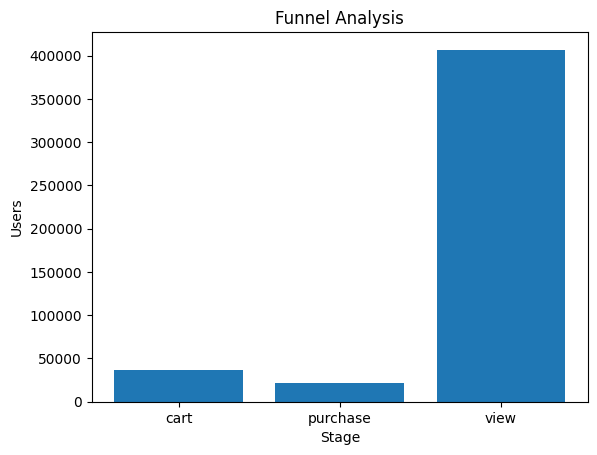

In [34]:
#Visualize Funnel
import matplotlib.pyplot as plt

plt.figure()
plt.bar(funnel_df['stage'], funnel_df['users'])
plt.title("Funnel Analysis")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.show()

In [36]:
# Insights

# Significant drop from View to Cart suggests weak product interest or UX issues
# Cart to purchase conversion is relatively higher, indicating intent once added to cart

In [37]:
#Check categories
df['category_code'].nunique()

107

In [38]:
df['category_code'].value_counts().head(10)

category_code
computers.components.videocards     116717
electronics.telephone                84360
computers.peripherals.printer        43224
stationery.cartrige                  38725
electronics.audio.acoustic           26766
computers.components.motherboard     26604
computers.notebook                   25032
computers.components.cpu             24773
electronics.video.tv                 21398
electronics.tablet                   19382
Name: count, dtype: int64

In [39]:
#Conversion table by Category

category_funnel = df.pivot_table(
    index = 'category_code',
    columns='event_type',
    values='user_id',
    aggfunc='nunique'
).fillna(0)

category_funnel.head()

event_type,cart,purchase,view
category_code,,,
accessories.bag,52.0,33.0,1165.0
accessories.briefcase,2.0,0.0,8.0
apparel.glove,1.0,0.0,83.0
appliances.environment.air_heater,18.0,11.0,537.0
appliances.environment.fan,1.0,0.0,60.0


In [41]:
#Conversion rates

category_funnel['view_to_cart']= category_funnel['cart']/category_funnel['view']
category_funnel['cart_to_purchase']= category_funnel['purchase']/category_funnel['cart']

In [42]:
#Handle error
#replace infinite value with 0

category_funnel = category_funnel.replace([float('inf')],0)

In [43]:
category_funnel.head()

event_type,cart,purchase,view,View_to_cart,view_to_cart,cart_to_purchase
category_code,,,,,,
accessories.bag,52.0,33.0,1165.0,0.044635,0.044635,0.634615
accessories.briefcase,2.0,0.0,8.0,0.250000,0.250000,0.000000
apparel.glove,1.0,0.0,83.0,0.012048,0.012048,0.000000
appliances.environment.air_heater,18.0,11.0,537.0,0.033520,0.033520,0.611111
appliances.environment.fan,1.0,0.0,60.0,0.016667,0.016667,0.000000


In [44]:
#Identify top performing categories

In [47]:
#sort by conversion rate

#top performing
category_funnel.sort_values('cart_to_purchase',ascending=False).head(10)

event_type,cart,purchase,view,View_to_cart,view_to_cart,cart_to_purchase
category_code,,,,,,
computers.peripherals.vr,4.0,5.0,127.0,0.031496,0.031496,1.250000
auto.accessories.light,1.0,1.0,28.0,0.035714,0.035714,1.000000
electronics.calculator,6.0,6.0,102.0,0.058824,0.058824,1.000000
auto.accessories.immobilizer,2.0,2.0,52.0,0.038462,0.038462,1.000000
appliances.personal.scales,3.0,3.0,428.0,0.007009,0.007009,1.000000
kids.toys,4.0,4.0,119.0,0.033613,0.033613,1.000000
appliances.kitchen.toster,1.0,1.0,143.0,0.006993,0.006993,1.000000
country_yard.weather_station,7.0,6.0,306.0,0.022876,0.022876,0.857143
stationery.stapler,37.0,30.0,375.0,0.098667,0.098667,0.810811


In [48]:
#worst performing
category_funnel.sort_values('cart_to_purchase',ascending=True).head(10)

event_type,cart,purchase,view,View_to_cart,view_to_cart,cart_to_purchase
category_code,,,,,,
furniture.bathroom.bath,1.0,0.0,25.0,0.040000,0.040000,0.0
accessories.briefcase,2.0,0.0,8.0,0.250000,0.250000,0.0
apparel.glove,1.0,0.0,83.0,0.012048,0.012048,0.0
electronics.fax,1.0,0.0,271.0,0.003690,0.003690,0.0
appliances.environment.fan,1.0,0.0,60.0,0.016667,0.016667,0.0
country_yard.watering,1.0,0.0,36.0,0.027778,0.027778,0.0
furniture.bedroom.blanket,2.0,0.0,14.0,0.142857,0.142857,0.0
jewelry.ring,3.0,0.0,26.0,0.115385,0.115385,0.0
appliances.kitchen.washer,1.0,0.0,55.0,0.018182,0.018182,0.0


In [49]:
#Keep categories with enough traffic

filtered = category_funnel[category_funnel['view']>1000]

In [51]:
#Top Categories - filtered

top_categories = filtered.sort_values('cart_to_purchase',ascending=False).head(10)
top_categories

event_type,cart,purchase,view,View_to_cart,view_to_cart,cart_to_purchase
category_code,,,,,,
appliances.environment.vacuum,263.0,194.0,3838.0,0.068525,0.068525,0.737643
appliances.kitchen.kettle,56.0,40.0,1379.0,0.040609,0.040609,0.714286
stationery.paper,73.0,50.0,1146.0,0.063700,0.063700,0.684932
computers.peripherals.camera,479.0,328.0,2070.0,0.231401,0.231401,0.684760
appliances.kitchen.meat_grinder,63.0,43.0,1427.0,0.044149,0.044149,0.682540
stationery.cartrige,2181.0,1475.0,20907.0,0.104319,0.104319,0.676295
computers.notebook,1287.0,856.0,13146.0,0.097901,0.097901,0.665113
computers.desktop,250.0,165.0,2994.0,0.083500,0.083500,0.660000
computers.peripherals.wifi,359.0,232.0,3748.0,0.095784,0.095784,0.646240


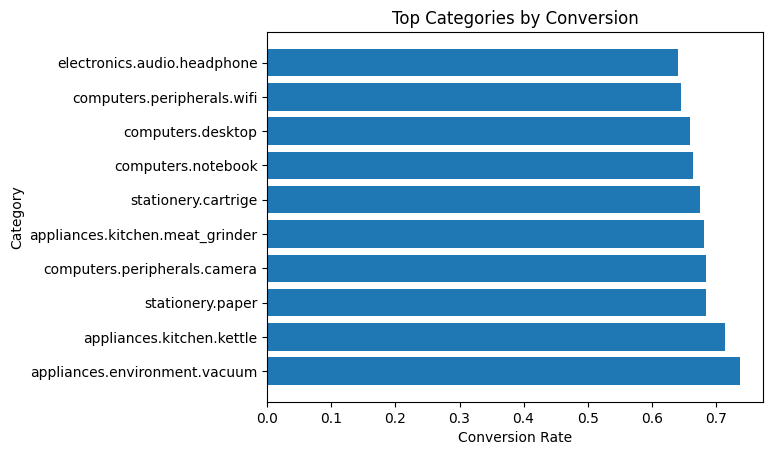

In [54]:
#Visualise top categories

plt.figure()
plt.barh(top_categories.index,  top_categories['cart_to_purchase'])
plt.title("Top Categories by Conversion")
plt.xlabel("Conversion Rate")
plt.ylabel("Category")
plt.show()

In [55]:
# Key Insights

# Certain categories show significantly higher conversion rates, indicating strong purchase intent
# Some high-traffic categories have low conversion, suggesting UX, pricing, or trust issues
# Filtering low-traffic categories helped avoid misleading insights

In [56]:
#Session Analysis

In [58]:
df = df.sort_values (['user_id','event_time'])

In [59]:
#Create time difference

df['time_diff']=df.groupby('user_id')['event_time'].diff()

In [60]:
#Define new session (gap > 30 mins then consider it as new session)

df['new_session']=df['time_diff'] >pd.Timedelta(minutes=30)

In [65]:
#Create session ID (cumsum() - running total)

df['session_id']=df.groupby('user_id')['new_session'].cumsum()

In [67]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,time_diff,new_session,session_id
174670,2020-10-29 11:28:35+00:00,view,4101974,2144415939364389423,electronics.clocks,honor,76.48,1515915625353226922,7qejzWzHlR,NaT,False,0
51155,2020-10-06 06:30:32+00:00,view,3506650,2144415935673401802,NaN,kester,28.98,1515915625353230067,ikPKHkuRhA,NaT,False,0
242211,2020-11-09 08:52:51+00:00,view,124883,2144415924424278172,electronics.audio.acoustic,logitech,23.90,1515915625353230683,dn9FkZ11dA,NaT,False,0
242297,2020-11-09 09:04:34+00:00,view,760044,2144415924424278172,electronics.audio.acoustic,dell,48.73,1515915625353230683,dn9FkZ11dA,0 days 00:11:43,False,0
242335,2020-11-09 09:08:53+00:00,view,125325,2144415924424278172,electronics.audio.acoustic,logitech,23.90,1515915625353230683,dn9FkZ11dA,0 days 00:04:19,False,0
242344,2020-11-09 09:10:59+00:00,view,461533,2144415924424278172,electronics.audio.acoustic,smartbuy,12.94,1515915625353230683,dn9FkZ11dA,0 days 00:02:06,False,0
242379,2020-11-09 09:15:27+00:00,view,1399881,2144415924424278172,electronics.audio.acoustic,sven,28.52,1515915625353230683,dn9FkZ11dA,0 days 00:04:28,False,0
242419,2020-11-09 09:22:00+00:00,view,1038457,2144415924424278172,electronics.audio.acoustic,bbk,16.84,1515915625353230683,dn9FkZ11dA,0 days 00:06:33,False,0
242442,2020-11-09 09:25:34+00:00,view,886608,2144415924424278172,electronics.audio.acoustic,perfeo,13.32,1515915625353230683,dn9FkZ11dA,0 days 00:03:34,False,0
242447,2020-11-09 09:26:38+00:00,view,3793158,2144415924424278172,electronics.audio.acoustic,canyon,10.03,1515915625353230683,dn9FkZ11dA,0 days 00:01:04,False,0


In [68]:
#Create session length

session_length = df.groupby(['user_id', 'session_id'])['event_time'].agg(['min', 'max'])

session_length['duration'] = session_length['max'] - session_length['min']

session_length.head()

min  \
user_id             session_id                             
1515915625353226922 0          2020-10-29 11:28:35+00:00   
1515915625353230067 0          2020-10-06 06:30:32+00:00   
1515915625353230683 0          2020-11-09 08:52:51+00:00   
                    1          2020-11-18 10:51:35+00:00   
                    2          2020-12-12 10:33:09+00:00   

                                                     max        duration  
user_id             session_id                                            
1515915625353226922 0          2020-10-29 11:28:35+00:00 0 days 00:00:00  
1515915625353230067 0          2020-10-06 06:30:32+00:00 0 days 00:00:00  
1515915625353230683 0          2020-11-09 09:26:38+00:00 0 days 00:33:47  
                    1          2020-11-18 10:59:26+00:00 0 days 00:07:51  
                    2          2020-12-12 10:33:09+00:00 0 days 00:00:00

In [70]:
#Events per session

events_per_session = df.groupby(['user_id','session_id']).size()
events_per_session.head()

user_id              session_id
1515915625353226922  0             1
1515915625353230067  0             1
1515915625353230683  0             8
                     1             4
                     2             1
dtype: int64

In [72]:
#Key metrics

print("Avg session duration:", session_length['duration'].mean())
print("Avg events per session",events_per_session.mean())

Avg session duration: 0 days 00:02:02.190618194
Avg events per session 1.753845513682955


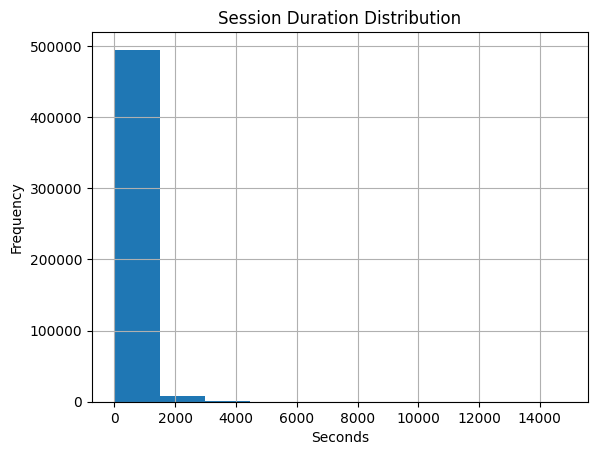

In [73]:
#Visualise session duration

session_length['duration'].dt.seconds.hist()
plt.title("Session Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.show()

In [74]:
# Session Insights

# Average session duration indicates user engagement level
# Sessions with more events are more likely to convert
# Short sessions may indicate poor UX or irrelevant traffic

In [75]:
#Cohort Analysis (Retention Analysis)

In [76]:
#Extract Month

df['event_month']=df['event_time'].dt.to_period('M')

/var/folders/4l/_m9wfdts0578mpl6h8dxdrx40000gn/T/ipykernel_12019/2479234256.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['event_month']=df['event_time'].dt.to_period('M')


In [77]:
#Find first purchase month

df['cohort_month']=df.groupby('user_id')['event_month'].transform('min')

In [78]:
#Cohort Index (Time since joining)

df['cohort_index']=(df['event_month']-df['cohort_month']).apply(lambda x: x.n)

In [80]:
#Build cohort table

cohort_data = df.groupby(['cohort_month','cohort_index'])['user_id'].nunique().reset_index()

In [81]:
#Convert to pivot table

cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)

cohort_pivot

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09,15334.0,955.0,267.0,119.0,98.0,72.0
2020-10,83261.0,2227.0,678.0,444.0,279.0,NaN
2020-11,90106.0,1867.0,792.0,552.0,NaN,NaN
2020-12,69473.0,1644.0,710.0,NaN,NaN,NaN
2021-01,78278.0,2162.0,NaN,NaN,NaN,NaN
2021-02,70831.0,NaN,NaN,NaN,NaN,NaN


In [82]:
#Convert to retention %

cohort_retention = cohort_pivot.divide(cohort_pivot[0],axis=0)
cohort_retention

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2020-09,1.0,0.062280,0.017412,0.007761,0.006391,0.004695
2020-10,1.0,0.026747,0.008143,0.005333,0.003351,NaN
2020-11,1.0,0.020720,0.008790,0.006126,NaN,NaN
2020-12,1.0,0.023664,0.010220,NaN,NaN,NaN
2021-01,1.0,0.027620,NaN,NaN,NaN,NaN
2021-02,1.0,NaN,NaN,NaN,NaN,NaN


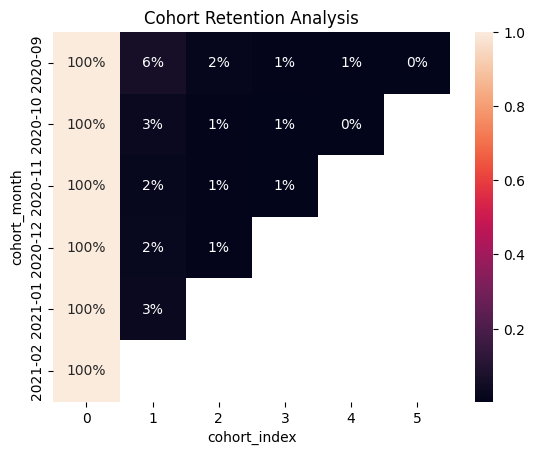

In [83]:
#Visualise retention (Heatmap)

import seaborn as sns

plt.figure()
sns.heatmap(cohort_retention, annot=True, fmt=".0%")
plt.title("Cohort Retention Analysis")
plt.show()

In [84]:
# Cohort Insights

# Retention drops significantly after the first month, indicating weak user stickiness
# Some cohorts perform better, possibly due to marketing or product changes
# Improving early retention (Month 1) can significantly impact long-term revenue